### Classify movie reviews into positive" reviews and "negative" reviews, just based on the text content of the reviews using DNN


### Import Lib

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [3]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense

### Load Dataset

In [4]:
df = pd.read_csv('IMDB.csv', encoding='latin1')

https://drive.google.com/file/d/18fGXFSE_VLVzCXB4BtwjtevbpMNJp8hM

In [5]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### Features Explanation

In [6]:
print("\nDataset Shape:", df.shape)


Dataset Shape: (50000, 2)


In [7]:
df.columns

Index(['review', 'sentiment'], dtype='object')

### Encode Labels

In [8]:
encoder = LabelEncoder()
df['sentiment'] = encoder.fit_transform(df['sentiment'])

In [9]:
# positive → 1
# negative → 0

df['sentiment'].value_counts()

sentiment
1    25000
0    25000
Name: count, dtype: int64

###  Train Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'],
    df['sentiment'],
    test_size=0.2,
    random_state=42
)

### Tokenization

In [11]:
vocab_size = 10000

tokenizer = Tokenizer(num_words=vocab_size)

tokenizer.fit_on_texts(X_train)

In [12]:
# Convert text → sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [13]:
print("\nExample Sequence:")
print(X_train_seq[0])


Example Sequence:
[197, 48, 10, 801, 2160, 534, 302, 1, 107, 1907, 2038, 4324, 6550, 2, 815, 4844, 12, 1, 227, 1, 6190, 79, 782, 53, 52, 22, 101, 4, 1, 27, 2009, 102, 36, 25, 34, 119, 1130, 12, 9, 6, 2366, 1190, 5, 454, 48, 552, 5, 92, 33, 23, 39, 916, 400, 15, 1, 166, 5, 2994, 24, 4359, 20, 3, 2945, 12, 45, 75, 221, 73, 126, 8, 81, 3155, 195, 20, 239, 2, 1, 447, 7, 7, 10, 205, 4982, 144, 21, 63, 27, 15, 74, 365, 302, 3, 19, 18, 9, 205, 26, 307, 12, 14, 1, 115, 439, 2, 14, 1, 1704, 615, 70, 424, 381, 10, 89, 118, 48, 112, 370, 33, 35, 18, 43, 10, 13, 92, 485, 6830, 15, 3, 364, 1182, 61, 8, 1, 470, 216, 1014, 5, 4160, 8, 3, 174, 4, 34, 440, 697, 623, 12, 3748, 237, 111, 848, 35, 170, 30, 219, 197, 1, 428, 367, 55, 3765, 3, 278, 7, 7, 157, 1707, 187, 6, 1, 727, 1935, 1, 1200, 4, 2946, 3749, 1828, 2, 147, 144, 3, 228, 4, 3, 207, 323, 2, 144, 1083, 16, 88, 4, 132, 2871, 8743, 18, 10, 153, 9253, 99, 4, 1, 4020, 302, 11, 17, 1001, 35, 1, 496, 492, 2619, 249, 71, 77, 107, 107, 698, 60, 86, 1

### Build DNN Model

In [14]:
max_length = 200


In [15]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post'
)


In [16]:
X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post'
)


In [17]:
print("\nShape after Padding:")
print(X_train_pad.shape)


Shape after Padding:
(40000, 200)


### Build DNN Model

In [18]:
model = Sequential([
    
    Embedding(input_dim=vocab_size, output_dim=32),

    Flatten(),

    Dense(64, activation='relu'),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

In [19]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [20]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Train Model

In [21]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=128,
    validation_split=0.2
)


Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.6505 - loss: 0.5773 - val_accuracy: 0.8715 - val_loss: 0.3042
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9335 - loss: 0.1817 - val_accuracy: 0.8604 - val_loss: 0.3393
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9883 - loss: 0.0418 - val_accuracy: 0.8570 - val_loss: 0.4646
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9986 - loss: 0.0087 - val_accuracy: 0.8574 - val_loss: 0.5876
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.9998 - loss: 0.0012 - val_accuracy: 0.8565 - val_loss: 0.6519


### Evaluate Model

In [22]:
loss, accuracy = model.evaluate(X_test_pad, y_test)

print("\nTest Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8493 - loss: 0.6745

Test Accuracy: 0.8567000031471252


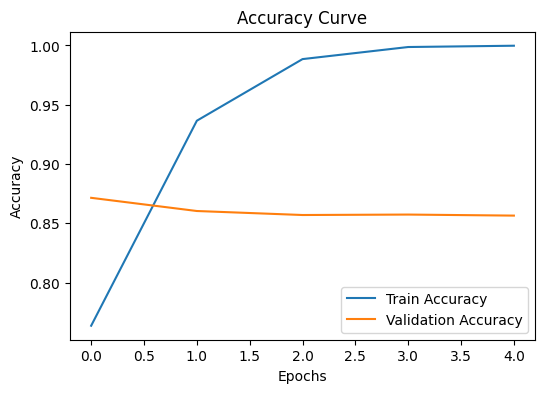

In [23]:
#Accuracy Graph
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")

plt.legend()

plt.show()

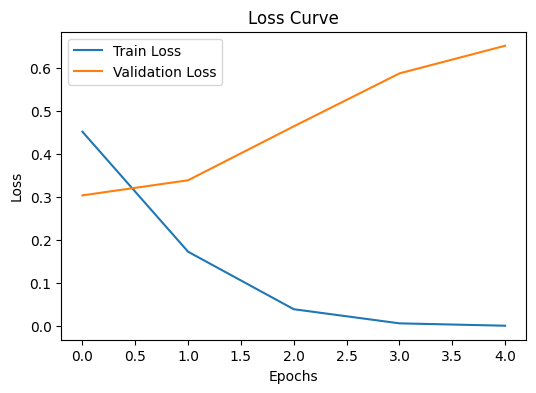

In [24]:
#Loss Graph
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.legend()

plt.show()


### Predictions

In [25]:
y_pred = (model.predict(X_test_pad) > 0.5).astype("int32")


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


### Confusion Matrix

In [26]:
print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=['Negative', 'Positive']
))



Classification Report:

              precision    recall  f1-score   support

    Negative       0.86      0.84      0.85      4961
    Positive       0.85      0.87      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



### Confusion Matrix

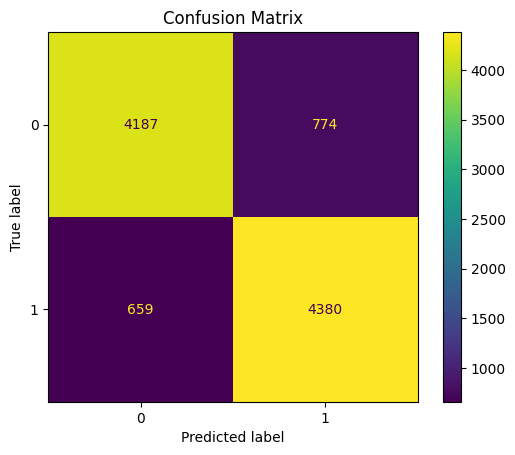

In [27]:

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")

plt.show()